# Analysis of the sampling frequency

count    7289.000000
mean        0.001000
std         0.000031
min         0.000047
25%         0.000998
50%         0.001000
75%         0.001002
max         0.001674
dtype: float64


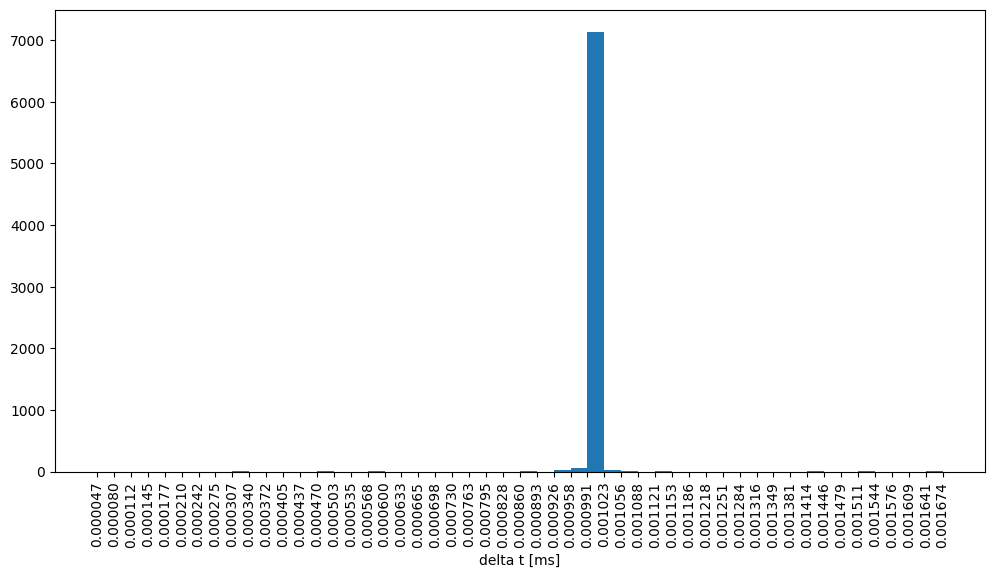

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import glob
import numpy as np

pd.set_option('display.max_rows', None)

# Load behavioral results
df = pd.read_csv("./data/trial_results.csv")

# Get paths from CSV file and change them to paths relative to the CSV
df["path"] = df['realtimepositiontracker_movement_location_0'].apply(
    lambda x: '/'.join(str(x).split('/')[-2:]) if isinstance(x, str) else x
)

data1 = pd.read_csv("./data/trackers/realtimepositiontracker_movement_T001.csv")

#print(df["real_start_time"][1])
# print(data1[["time", "time"]])

deltas = []
events = []
for i in range(len(data1)-1):
    deltas += [data1.iloc[i+1]["time"] - data1.iloc[i]["time"]]
    events += [data1.iloc[i]["event"]]

deltas_and_events = list(zip(deltas, events))

print(pd.Series(deltas).describe(include='all'))

outliers = [(i, d) for i, d in enumerate(deltas) if d > 2 * np.mean(deltas)]

for i, d in outliers:
    print((i, deltas_and_events[i-5:i+5]))

plt.figure(figsize=(12, 6))  # width, height in inches
counts, bins, _ = plt.hist(deltas, bins=50)
plt.xlabel("delta t [ms]")
plt.xticks(bins, rotation=90)
plt.show()

# Example plots of pen movement from real trials

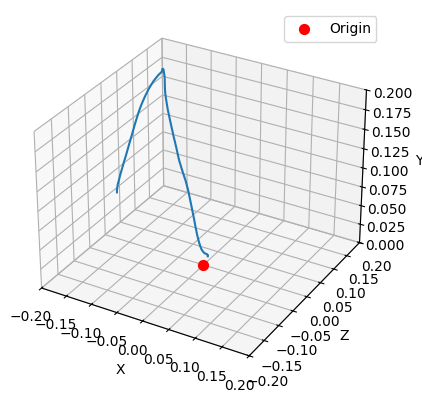

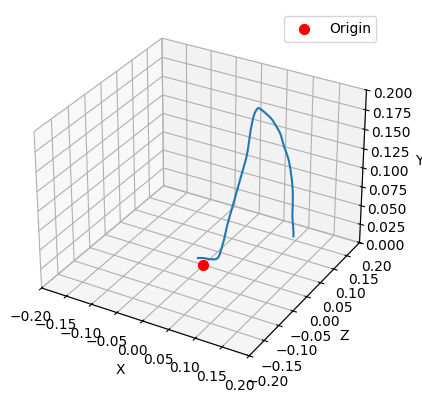

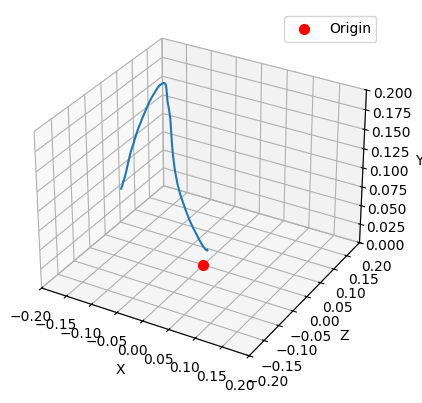

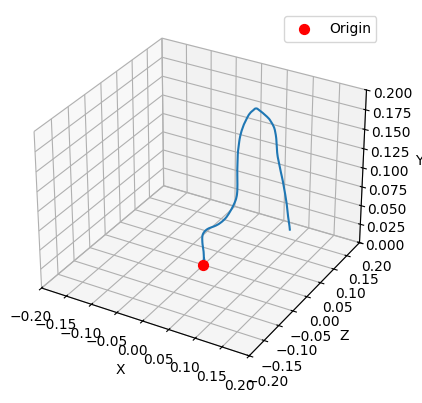

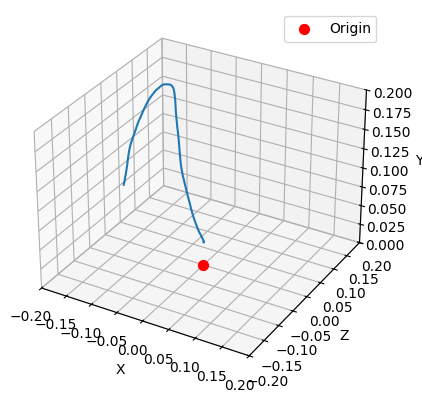

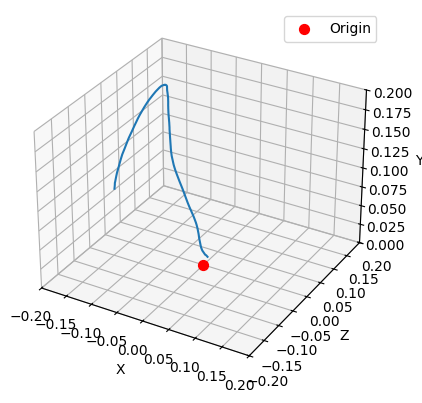

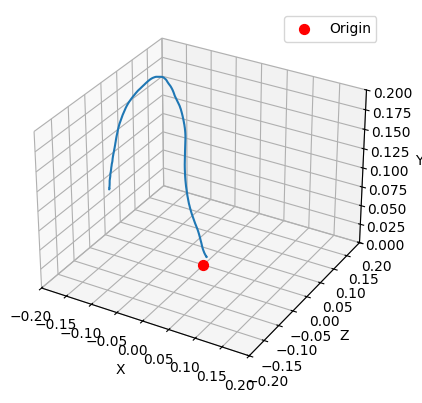

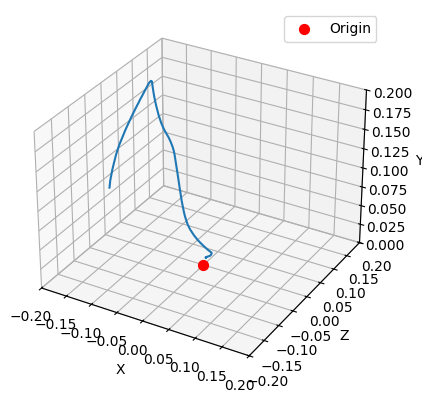

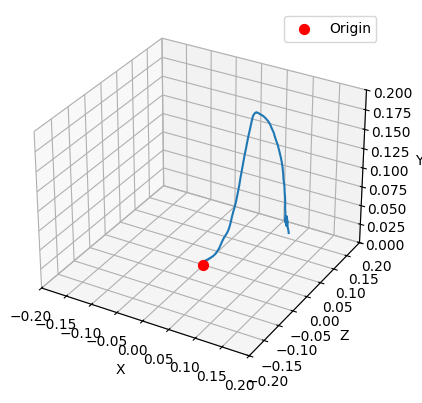

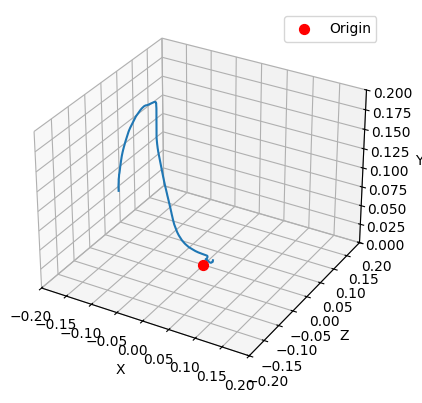

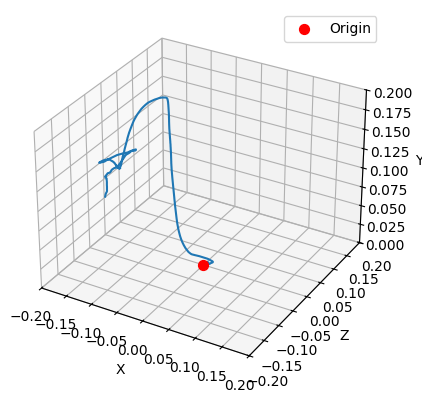

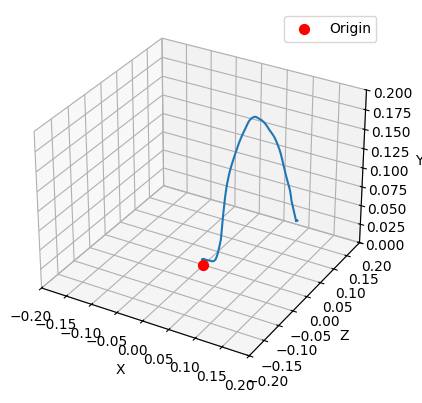

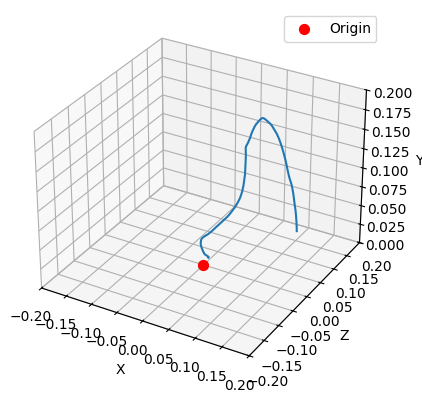

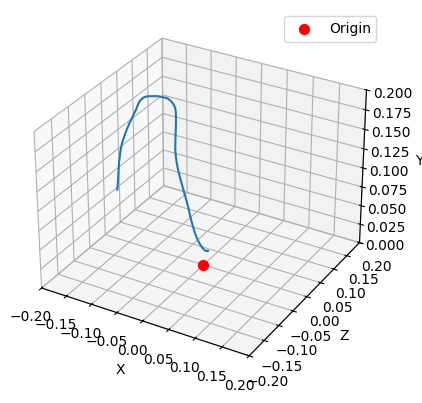

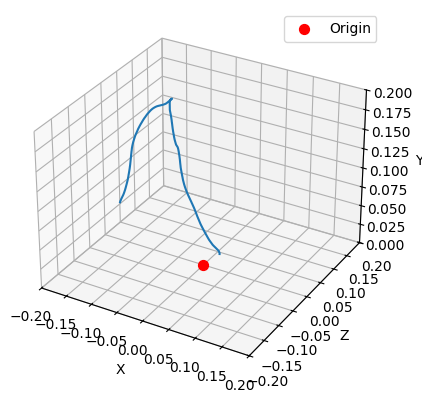

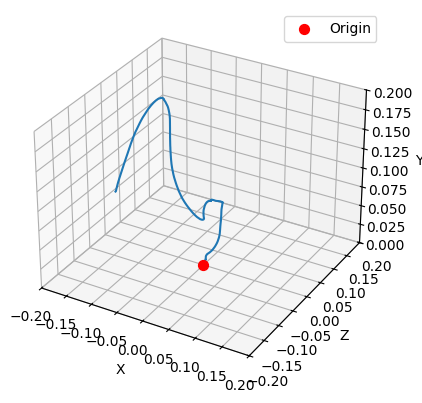

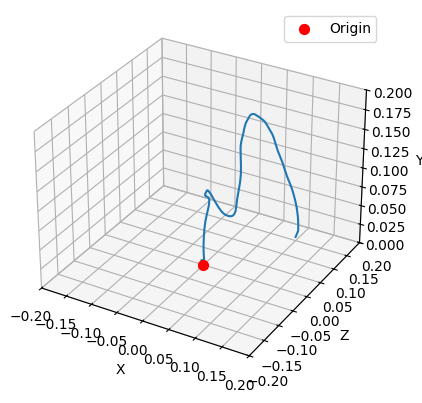

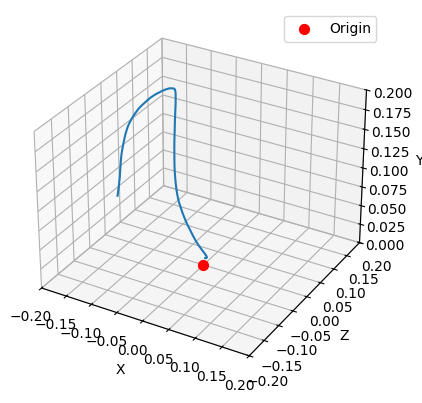

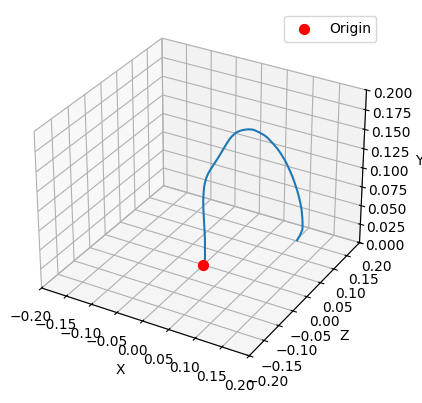

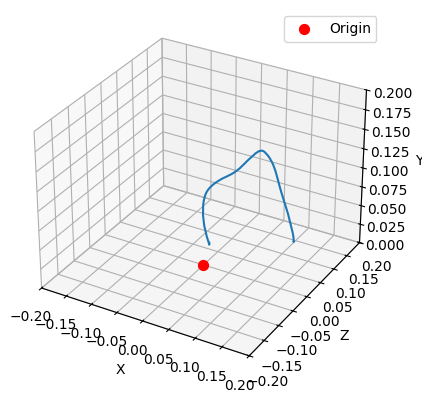

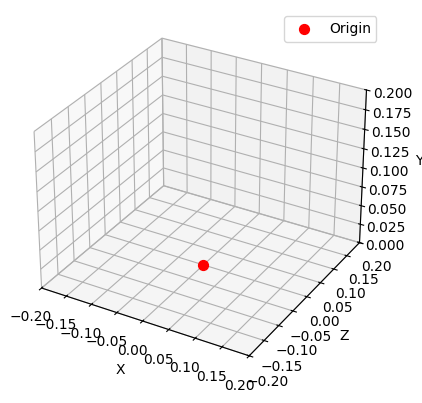

In [8]:
# Loop over all trials
for file in "data/" + df["path"].dropna():
    # Load CSV
    df = pd.read_csv(file)

    # Only while ball is grabbed
    df = df[df["event"] == "ball_grabbed"]

    # 3D Plot
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(df['pos_x'], df['pos_z'], df['pos_y'])

    ax.set_xlabel('X')
    ax.set_ylabel('Z')
    ax.set_zlabel('Y')

    # mark the origin
    ax.scatter(0, 0, 0, color='red', s=50, label='Origin')
    ax.legend()

    # constant limits
    ax.set_xlim([-0.2, 0.2])
    ax.set_ylim([-0.2, 0.2])
    ax.set_zlim([0, 0.2])

    plt.show()